In [92]:
from Kea.utils import plotting
import numpy as np
import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

c = plotting.COLOR_CYCLE_6

L = 5.*np.pi
_N = 256

from sympy import *

In [93]:
k = symbols('k', real=True)
s = symbols('sigma', real=True, positive=True)
xi = symbols('xi', real=True, positive=True)
D = symbols('D', integer=True, positive=True)

f = k**(D-1) * Abs(k**2 * s**2 * xi * exp(-k**2 * s**2 / 2))**2
display(f)

k**4*k**(D - 1)*sigma**4*xi**2*exp(-k**2*sigma**2)

In [94]:
display(maximum(f.subs({D: 2}), k))

25*sqrt(10)*xi**2*exp(-5/2)/(8*sigma)

In [95]:
diff_f = diff(f, k)
display(diff_f)
critical_points = solve(diff_f, k)
for point in critical_points:
    if point == 0:
        continue
    display(point)
    display(f.subs(k, point))
kmax = critical_points[-1]

-2*k**5*k**(D - 1)*sigma**6*xi**2*exp(-k**2*sigma**2) + k**3*k**(D - 1)*sigma**4*xi**2*(D - 1)*exp(-k**2*sigma**2) + 4*k**3*k**(D - 1)*sigma**4*xi**2*exp(-k**2*sigma**2)

-sqrt(2*D + 6)/(2*sigma)

xi**2*(-sqrt(2*D + 6)/(2*sigma))**(D - 1)*(2*D + 6)**2*exp(-D/2 - 3/2)/16

sqrt(2*D + 6)/(2*sigma)

xi**2*(sqrt(2*D + 6)/(2*sigma))**(D - 1)*(2*D + 6)**2*exp(-D/2 - 3/2)/16

In [96]:
fD = f.subs({D: 3})

d_f = diff(fD, k)
dd_f = diff(fD, k, 2)
critical_points = solve(d_f, k)
for point in critical_points:
    if dd_f.subs(k, point) < 0:
        print(f"Local maximum at x={point} with f({point})={fD.subs(k, point)}")
    elif dd_f.subs(k, point) > 0:
        print(f"Local minimum at x={point} with f({point})={fD.subs(k, point)}")
    else:
        print(f"Inconclusive at x={point} with f({point})={fD.subs(k, point)}")

Inconclusive at x=0 with f(0)=0
Local maximum at x=-sqrt(3)/sigma with f(-sqrt(3)/sigma)=27*xi**2*exp(-3)/sigma**2
Local maximum at x=sqrt(3)/sigma with f(sqrt(3)/sigma)=27*xi**2*exp(-3)/sigma**2


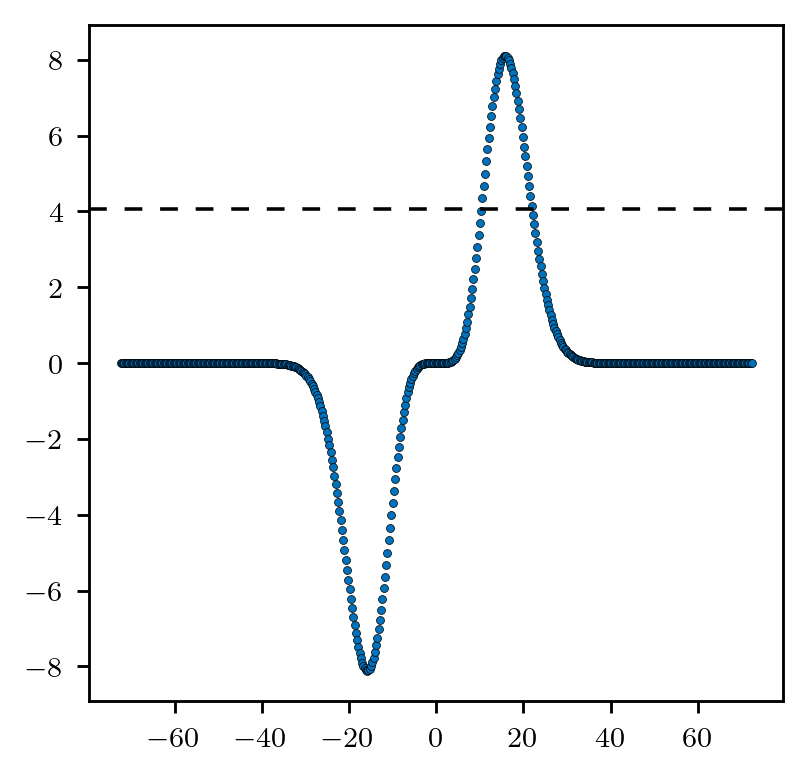

In [117]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

_D = 2
_xi = 1.
_s = 0.1

lam_f = lambdify(k, f.subs({D: _D, xi: _xi, s: _s}))

for _k in np.linspace(-np.sqrt(_D)*_N*np.pi/L, np.sqrt(_D)*_N*np.pi/L, 500):
    ax.scatter(_k, lam_f(_k), marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')

kmax_num = float(kmax.subs({D: _D, xi: _xi, s: _s}).evalf())
ax.axhline(lam_f(kmax_num)/2., linestyle=(0,(5,5)), color='black', linewidth=1.)

In [148]:
## FWHM BOUNDS
fD = f#.subs({D: 2})
kmaxD = kmax#.subs({D: 2})

halfmax = fD.subs({k: kmaxD})/2
eqf = Eq(fD, halfmax)
display(eqf)
critical_points = solve(eqf, k)
print(len(critical_points), 'solutions')
for point in critical_points:
    display(point)

Eq(k**4*k**(D - 1)*sigma**4*xi**2*exp(-k**2*sigma**2), xi**2*(sqrt(2*D + 6)/(2*sigma))**(D - 1)*(2*D + 6)**2*exp(-D/2 - 3/2)/32)

2 solutions


exp((-D - (D + 3)*LambertW(-exp((-D + log((D + 3)**(D + 3)/4) - 3)/(D + 3))/(D + 3)) + log(2**(-D - 5)*sigma**(-2*D - 6)*(D + 3)**(D + 3)) - 3)/(2*(D + 3)))

exp((-D - (D + 3)*LambertW(-exp((-D + 2*I*pi*D + log((D + 3)**(D + 3)/4) - 3 + 6*I*pi)/(D + 3))/(D + 3)) + log(2**(-D - 5)*sigma**(-2*D - 6)*(D + 3)**(D + 3)) - 3)/(2*(D + 3)))

In [128]:
critical_points[0].subs({D: 2, s: 5})

2**(3/10)*sqrt(5)*exp(-1/2 - LambertW(-2**(3/5)*exp(-1)/2)/2)/10

Text(0.5, 0, 'Gaussian width, $\\sigma$')

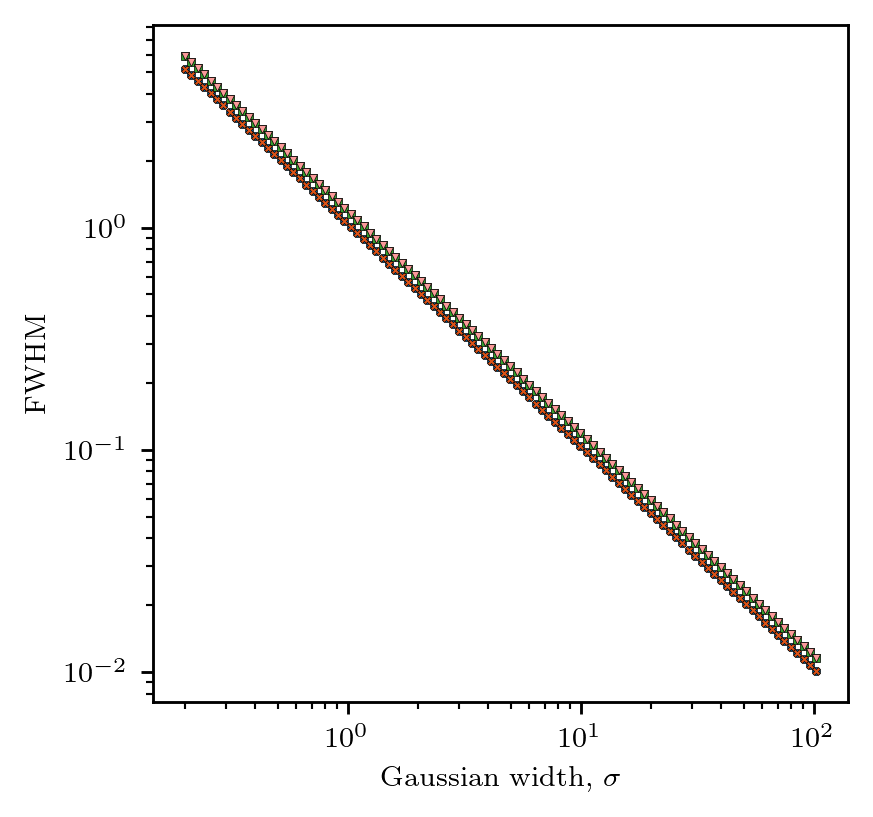

In [143]:
lam_wp2 = lambdify(s, critical_points[0].subs({D: 2}))
lam_wm2 = lambdify(s, critical_points[1].subs({D: 2}))

lam_wp3 = lambdify(s, critical_points[0].subs({D: 3}))
lam_wm3 = lambdify(s, critical_points[1].subs({D: 3}))

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)
for _s in np.exp(np.linspace(np.log(np.pi/L), np.log(2*_N*np.pi/L), 100)):
    ax.scatter(_s, lam_wp2(_s), marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')
    ax.scatter(_s, lam_wm2(_s), marker='X', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')

    ax.scatter(_s, lam_wp3(_s), marker='s', s=5., color=c[2], zorder=2, linewidth=0.2, edgecolor='black')
    ax.scatter(_s, lam_wm3(_s), marker='v', s=5., color=c[3], zorder=2, linewidth=0.2, edgecolor='black')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel('FWHM')
ax.set_xlabel('Gaussian width, $\sigma$')

/home/m/.local/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


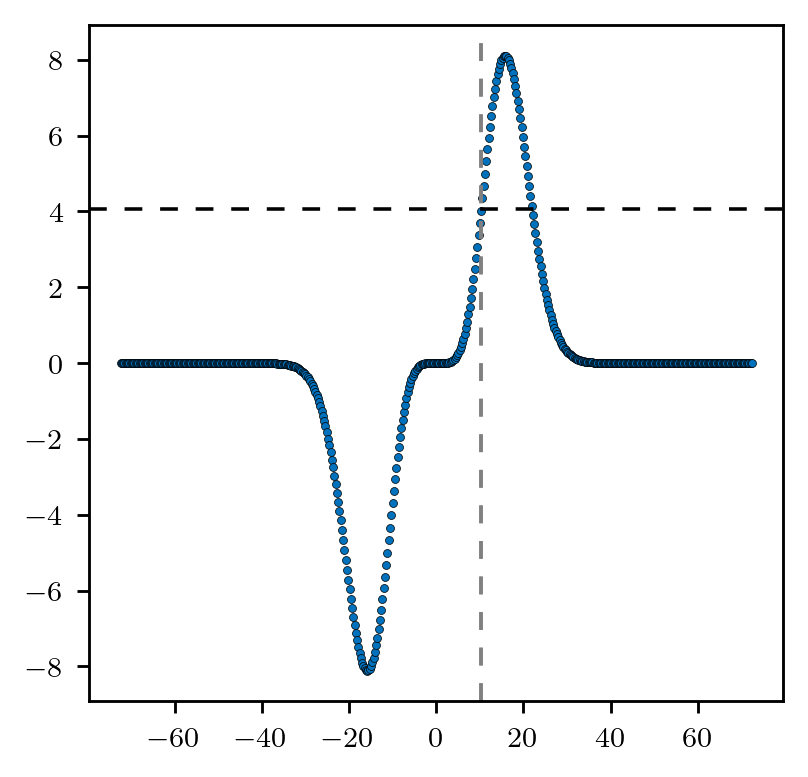

In [136]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

_D = 2
_xi = 1.
_s = 0.1

lam_f = lambdify(k, f.subs({D: _D, xi: _xi, s: _s}))

for _k in np.linspace(-np.sqrt(_D)*_N*np.pi/L, np.sqrt(_D)*_N*np.pi/L, 500):
    ax.scatter(_k, lam_f(_k), marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')

kmax_num = float(kmax.subs({D: _D, xi: _xi, s: _s}).evalf())
ax.axhline(lam_f(kmax_num)/2., linestyle=(0,(5,5)), color='black', linewidth=1.)
ax.axvline(lam_wp2(_s), linestyle=(0,(5,5)), color='gray', linewidth=1.)
ax.axvline(lam_wm2(_s), linestyle=(0,(5,5)), color='gray', linewidth=1.)

[0.02164982]


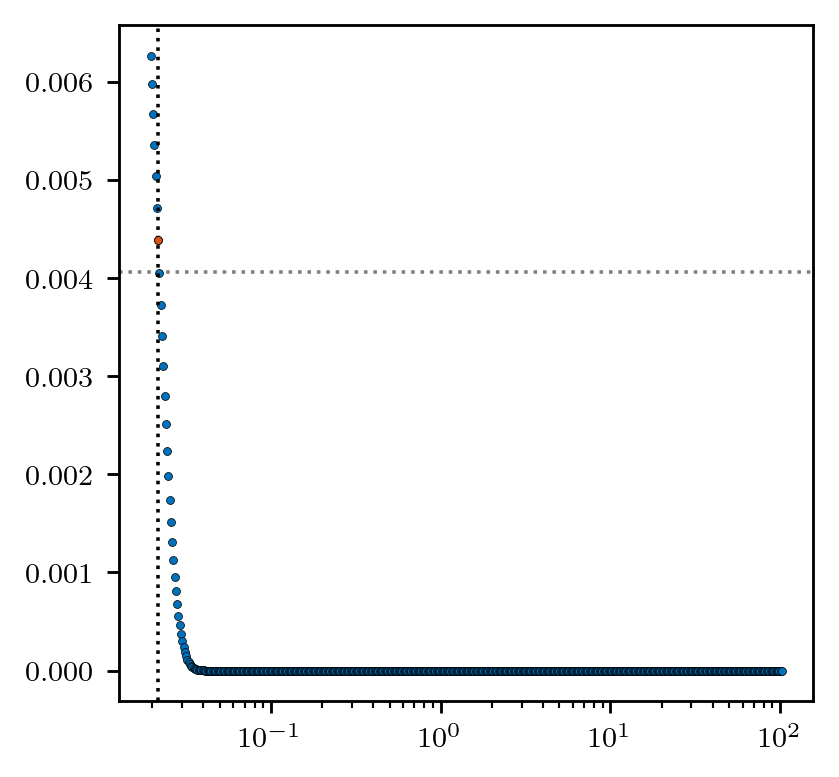

In [183]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

_D = 2
_xi = 1.
_s = 100.

lam_f = lambdify(k, f.subs({D: _D, xi: _xi, s: _s}))
kmax_num = float(kmax.subs({D: _D, xi: _xi, s: _s}).evalf())
HM = lam_f(kmax_num)/2.

ax.axhline(HM, color='gray', linestyle=':', linewidth=1.)

f_ar = []
kz = []
#for _k in np.linspace(-np.sqrt(_D)*_N*np.pi/L, np.sqrt(_D)*_N*np.pi/L, 500):
for _k in np.exp(np.linspace(-np.log(_N*np.pi/L), np.log(2*_N*np.pi/L), 500)):
    kz.append(_k)
    f_ar.append(lam_f(_k))
    ax.scatter(_k, lam_f(_k), marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')
f_ar = np.array(f_ar)
kz = np.array(kz)

HM_ar = np.ones_like(f_ar) * HM

idx = np.argwhere(np.diff(np.sign(f_ar - HM_ar))).flatten()
print(kz[idx])

for id in idx:
    ax.axvline(kz[id], color='black', linestyle=':', linewidth=1.)
    ax.scatter(kz[id], lam_f(kz[id]), marker='o', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')

ax.set_xscale('log')


In [184]:
def compute_intersect(_s):
    _D = 2
    _xi = 1.
    lam_f = lambdify(k, f.subs({D: _D, xi: _xi, s: _s}))
    kmax_num = float(kmax.subs({D: _D, xi: _xi, s: _s}).evalf())
    HM = lam_f(kmax_num)/2.
    f_ar = []
    kz = []
    #for _k in np.linspace(-np.sqrt(_D)*_N*np.pi/L, np.sqrt(_D)*_N*np.pi/L, 1000):
    #for _k in np.exp(np.linspace(0, np.log(2*_N*np.pi/L), 500)):
    for _k in np.exp(np.linspace(-np.log(_N*np.pi/L), np.log(2*_N*np.pi/L), 500)):
        kz.append(_k)
        f_ar.append(lam_f(_k))
    f_ar = np.array(f_ar)
    kz = np.array(kz)
    HM_ar = np.ones_like(f_ar) * HM
    idx = np.argwhere(np.diff(np.sign(f_ar - HM_ar))).flatten()
    return kz[idx]


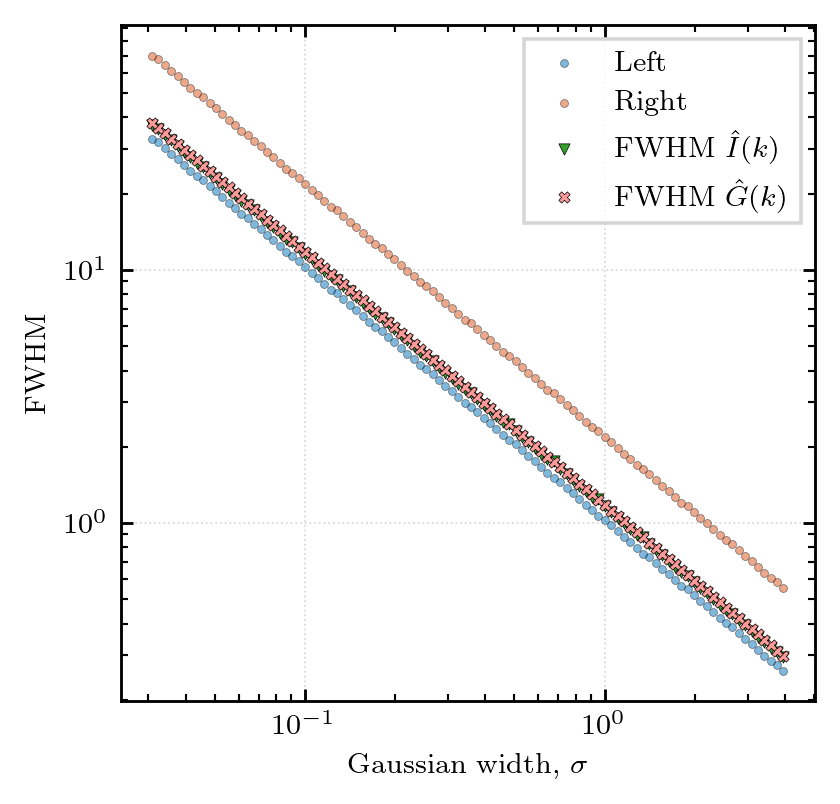

In [194]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

for _k in np.exp(np.linspace(np.log(2.*np.pi/L), np.log(_N*np.pi/L), 100)):
    _s = np.sqrt(2.*2. + 6.)/(2.*_k)
    idxs = compute_intersect(_s)

    for i, idx in enumerate(idxs):
        ax.scatter(_s, idx, marker='o', s=5., color=c[i], zorder=2, linewidth=0.2, edgecolor='black', alpha=0.5)

    if len(idxs) == 2:
        ax.scatter(_s, idxs[1] - idxs[0], marker='v', s=10., color=c[2], zorder=2, linewidth=0.2, edgecolor='black')

    ax.scatter(_s, np.sqrt(2.* np.log(2.)) / _s, marker='X', s=10., color=c[3], zorder=2, linewidth=0.2, edgecolor='black')

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlabel('Gaussian width, $\sigma$')
ax.set_ylabel('FWHM')

ax.scatter([], [], marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black', label='Left', alpha=0.5)
ax.scatter([], [], marker='o', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black', label='Right', alpha=0.5)
ax.scatter([], [], marker='v', s=10., color=c[2], zorder=2, linewidth=0.2, edgecolor='black', label='FWHM $\hat{I}(k)$')
ax.scatter([], [], marker='X', s=10., color=c[3], zorder=2, linewidth=0.2, edgecolor='black', label='FWHM $\hat{G}(k)$')

ax.legend(fancybox=False, frameon=True)

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
